# Perceptron Implementation

Perceptron is a  basic building block which is used for binary classifier that separates data.

## 🧠 Perceptron Algorithm

The Perceptron is a supervised machine learning algorithm used for **binary classification**.

It works by computing a weighted sum of input features and passing it through an activation function.

### Formula:
y = f(∑(wᵢxᵢ) + b)

Where:
- x = input features  
- w = weights  
- b = bias  
- f = activation function (step function)  

### Key Idea:
If the weighted sum is greater than 0 → Output = 1  
Else → Output = 0

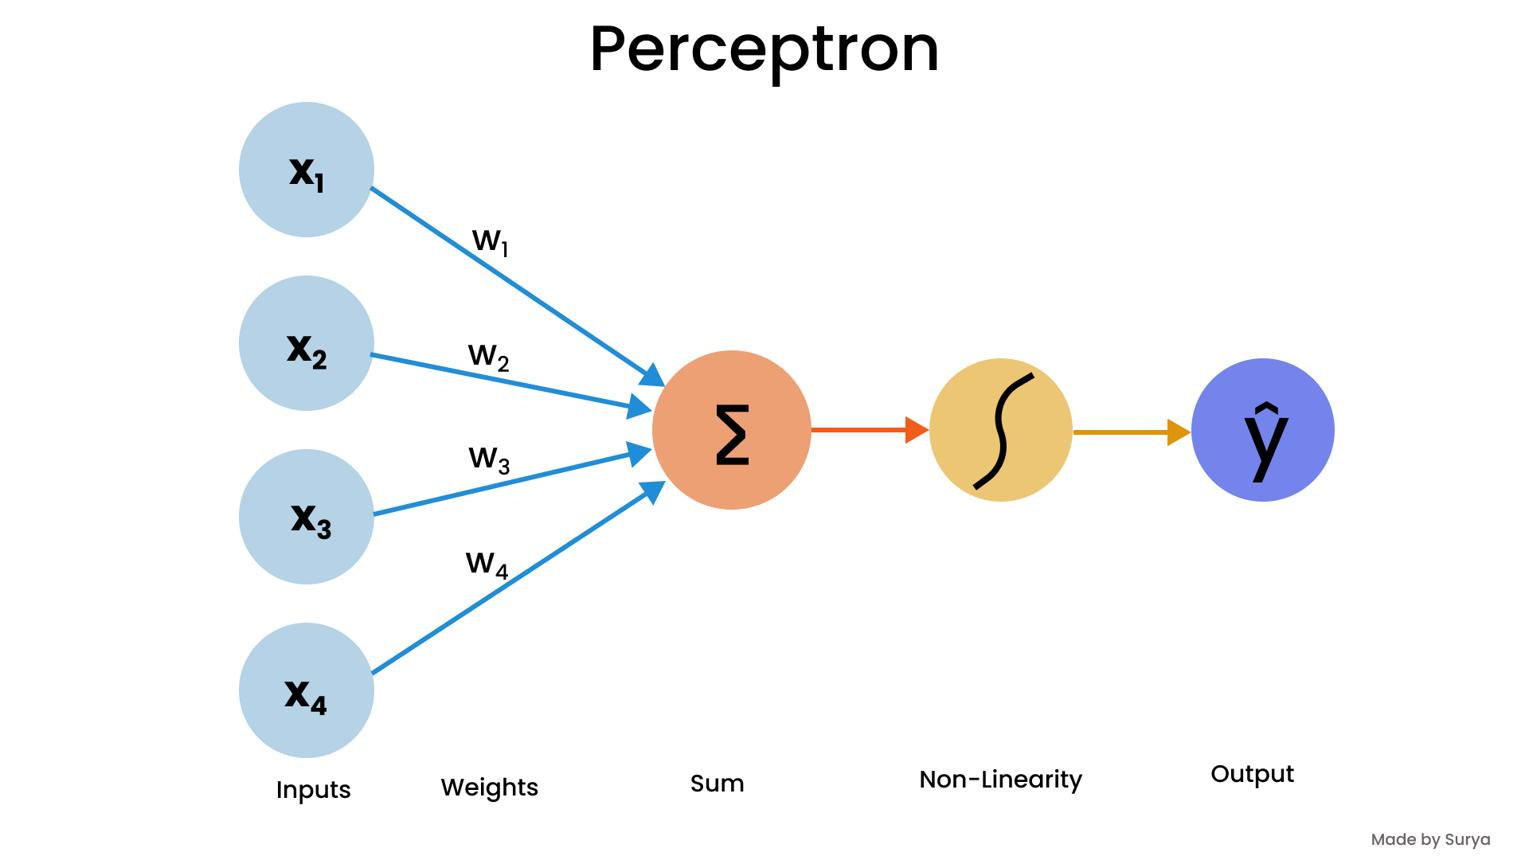

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('fivethirtyeight')

## 📊 Dataset (Manually Created)

In this notebook, we are using a small manually created dataset to understand how the perceptron works.

- X → Input features
- y → Output labels (0 or 1)

This data is **linearly separable**, which is required for perceptron to work correctly.

In [2]:
class Perceptron:
    def __init__(self, eta, epochs):
        self.weights = np.random.randn(3) * 1e-4
        print(f'self.weights: {self.weights}')
        self.eta = eta
        self.epochs = epochs

    def activationFunction(self, inputs, weights):
        z = np.dot(inputs, weights)
        return np.where(z > 0, 1, 0)

    def fit(self, X, y):
        self.X = X
        self.y = y

        X_with_bias = np.c_[self.X, -np.ones((len(self.X), 1))] # concatenation
        print(f'X_with_bias: \n{X_with_bias}')

        for epoch in range(self.epochs):
            print(f'for epoch: {epoch}')
            y_hat = self.activationFunction(X_with_bias, self.weights)
            print(f'predicted value: \n{y_hat}')
            error = self.y - y_hat
            print(f'error: \n{error}')
            self.weights = self.weights + self.eta * np.dot(X_with_bias.T, error)
            print(f'updated weights: \n{self.weights}')
            print("################\n")

    def predict(self, X):
        X_with_bias = np.c_[self.X, -np.ones((len(self.X), 1))]
        return self.activationFunction(X_with_bias, self.weights)

# AND Operation

In [3]:
data = {'x1': [0,0,1,1], 'x2': [0,1,0,1], 'y': [0,0,0,1]}

AND = pd.DataFrame(data)
AND

,x1,x2,y
0,0,0,0
1,0,1,0
2,1,0,0
3,1,1,1


In [4]:
X = AND.drop('y', axis = 1)
X

,x1,x2
0,0,0
1,0,1
2,1,0
3,1,1


In [5]:
y = AND['y']
y

0    0
1    0
2    0
3    1
Name: y, dtype: int64

In [6]:
model = Perceptron(eta = 0.5, epochs = 10)
model.fit(X, y)

self.weights: [-1.55663294e-06  7.94885199e-05  6.76159755e-05]
X_with_bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
for epoch: 0
predicted value: 
[0 1 0 1]
error: 
0    0
1   -1
2    0
3    0
Name: y, dtype: int64
updated weights: 
[-1.55663294e-06 -4.99920511e-01  5.00067616e-01]
################

for epoch: 1
predicted value: 
[0 0 0 0]
error: 
0    0
1    0
2    0
3    1
Name: y, dtype: int64
updated weights: 
[4.99998443e-01 7.94885199e-05 6.76159755e-05]
################

for epoch: 2
predicted value: 
[0 1 1 1]
error: 
0    0
1   -1
2   -1
3    0
Name: y, dtype: int64
updated weights: 
[-1.55663294e-06 -4.99920511e-01  1.00006762e+00]
################

for epoch: 3
predicted value: 
[0 0 0 0]
error: 
0    0
1    0
2    0
3    1
Name: y, dtype: int64
updated weights: 
[4.99998443e-01 7.94885199e-05 5.00067616e-01]
################

for epoch: 4
predicted value: 
[0 0 0 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[4.9999844

In [7]:
model.predict(X)

array([0, 0, 0, 1])

In [8]:
model.weights

array([4.99998443e-01, 7.94885199e-05, 5.00067616e-01])

# OR Operation

In [9]:
data = {'x1': [0,0,1,1], 'x2': [0,1,0,1], 'y': [0,1,1,1]}

OR = pd.DataFrame(data)
OR

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,1


In [10]:
X = OR.drop('y', axis = 1)
X

,x1,x2
0,0,0
1,0,1
2,1,0
3,1,1


In [11]:
y = OR['y']
y

0    0
1    1
2    1
3    1
Name: y, dtype: int64

In [12]:
model = Perceptron(eta = 0.5, epochs = 10)
model.fit(X, y)

self.weights: [-6.94590949e-05 -5.37972824e-06  7.50920517e-05]
X_with_bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
for epoch: 0
predicted value: 
[0 0 0 0]
error: 
0    0
1    1
2    1
3    1
Name: y, dtype: int64
updated weights: 
[ 0.99993054  0.99999462 -1.49992491]
################

for epoch: 1
predicted value: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[ 0.99993054  0.99999462 -0.99992491]
################

for epoch: 2
predicted value: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[ 0.99993054  0.99999462 -0.49992491]
################

for epoch: 3
predicted value: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[9.99930541e-01 9.99994620e-01 7.50920517e-05]
################

for epoch: 4
predicted value: 
[0 1 1 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[9.99930541e-01 9.99994620e-01 7.50920517e-

In [13]:
model.predict(X)

array([0, 1, 1, 1])

In [14]:
model.weights

array([9.99930541e-01, 9.99994620e-01, 7.50920517e-05])

# XOR Operation

In [15]:
data = {'x1': [0,0,1,1], 'x2': [0,1,0,1], 'y': [0, 1, 1, 0]}

XOR = pd.DataFrame(data)
XOR

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [16]:
X = XOR.drop('y', axis = 1)
X

,x1,x2
0,0,0
1,0,1
2,1,0
3,1,1


In [17]:
y = XOR['y']
y

0    0
1    1
2    1
3    0
Name: y, dtype: int64

In [18]:
model = Perceptron(eta = 0.5, epochs = 10)
model.fit(X, y)

self.weights: [1.75652111e-04 2.37692030e-05 1.30101718e-04]
X_with_bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
for epoch: 0
predicted value: 
[0 0 1 1]
error: 
0    0
1    1
2    0
3   -1
Name: y, dtype: int64
updated weights: 
[-4.99824348e-01  2.37692030e-05  1.30101718e-04]
################

for epoch: 1
predicted value: 
[0 0 0 0]
error: 
0    0
1    1
2    1
3    0
Name: y, dtype: int64
updated weights: 
[ 1.75652111e-04  5.00023769e-01 -9.99869898e-01]
################

for epoch: 2
predicted value: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3   -1
Name: y, dtype: int64
updated weights: 
[-4.99824348e-01  2.37692030e-05  1.30101718e-04]
################

for epoch: 3
predicted value: 
[0 0 0 0]
error: 
0    0
1    1
2    1
3    0
Name: y, dtype: int64
updated weights: 
[ 1.75652111e-04  5.00023769e-01 -9.99869898e-01]
################

for epoch: 4
predicted value: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3   -1
Name: y, dtype: int64
updated weights: 
[-4.998

In [19]:
model.predict(X)

array([1, 1, 1, 1])

In [20]:
model.weights

array([ 1.75652111e-04,  5.00023769e-01, -9.99869898e-01])

This simple dataset helps visualize how the perceptron learns a decision boundary.

## 📊 Observation

The perceptron successfully separates the manually created data using a linear boundary.

## 🌍 Real-World Note

In real applications, large datasets are used instead of manually created data.
Here, we use simple data to understand the core concept clearly.